In [2]:
import os
import pandas as pd
import statsmodels.api as sm
import scipy.stats as stats

In [ ]:
METHOD = "khodadad2018_200Hz_120s_all"

# Read the Excel file
excel_file_name = 'N2O-study2-data-for-Luka.xlsx'
excel_sheet_name = 'Sheet1'
excel_file_path = os.path.join("data_raw", excel_file_name)
excel_df = pd.read_excel(excel_file_path, sheet_name=excel_sheet_name)
excel_df = excel_df.sort_values(by=['ID', 'Session'])

# Read the CSV file
csv_file_name = f'lzc_{METHOD}_file_cond.csv'
csv_file_path = os.path.join(f"data_{METHOD}_lzc", csv_file_name)
csv_df = pd.read_csv(csv_file_path)
csv_df = csv_df.rename(columns={'session': 'phase'})
csv_df['ID'] = csv_df['file'].str[:4]
csv_df['Session'] = csv_df['file'].str[5].astype(int)
csv_df = csv_df.drop(columns=['file'])

df = pd.merge(excel_df, csv_df, on=['ID', 'Session'], how='inner')
df = df[['ID', 'Session', 'phase'] + [col for col in df.columns if col not in ['ID', 'Session', 'phase']]]

# print(excel_df)
# print(csv_df)
# print()
# print(df)
# print()
# print(f"DataFrame columns: {list(df.columns)}\n")

In [88]:
# Print average complexity for different conditions
print("\n" + "=" * 80)
print("T-TEST ANALYSIS")
print("=" * 80)

pre = df[df['phase'] == 'pre']['lzc_mean']
print(f"Mean LZC (PRE): {pre.mean():.4f} ± {pre.std():.4f} ({pre.count()} subject-session pairs)")

air = df[(df['phase'] == 'dur') & (df['Drug'] == 'Medical Air')]['lzc_mean']
print(f"Mean LZC (AIR): {air.mean():.4f} ± {air.std():.4f} ({air.count()} subject-session pairs)")

n2o = df[(df['phase'] == 'dur') & (df['Drug'] == 'N2O')]['lzc_mean']
print(f"Mean LZC (N2O): {n2o.mean():.4f} ± {n2o.std():.4f} ({n2o.count()} subject-session pairs)")

pre_vals = pre.dropna()
air_vals = air.dropna()
n2o_vals = n2o.dropna()

t_stat, p_val = stats.ttest_ind(air_vals, pre_vals, equal_var=False)
print(f"p-value (AIR vs PRE, Welch t-test): {p_val:.7f} (t={t_stat:.3f}) - {'NOT ' if p_val >= 0.05 else ''}SIGNIFICANT")

t_stat, p_val = stats.ttest_ind(n2o_vals, pre_vals, equal_var=False)
print(f"p-value (N2O vs PRE, Welch t-test): {p_val:.7f} (t={t_stat:.3f}) - {'NOT ' if p_val >= 0.05 else ''}SIGNIFICANT")

t_stat, p_val = stats.ttest_ind(n2o_vals, air_vals, equal_var=False)
print(f"p-value (N2O vs AIR, Welch t-test): {p_val:.7f} (t={t_stat:.3f}) - {'NOT ' if p_val >= 0.05 else ''}SIGNIFICANT")

print("=" * 80 + "\n")


T-TEST ANALYSIS
Mean LZC (PRE): 0.0158 ± 0.0032 (88 subject-session pairs)
Mean LZC (AIR): 0.0137 ± 0.0037 (73 subject-session pairs)
Mean LZC (N2O): 0.0132 ± 0.0028 (67 subject-session pairs)
p-value (AIR vs PRE, Welch t-test): 0.0001945 (t=-3.824) - SIGNIFICANT
p-value (N2O vs PRE, Welch t-test): 0.0000004 (t=-5.314) - SIGNIFICANT
p-value (N2O vs AIR, Welch t-test): 0.3829260 (t=-0.875) - NOT SIGNIFICANT



In [89]:
df['intercept'] = 1
df['gender'] = df['Gender'].map({'M': 0, 'F': 1})
# df['condition'] = pd.NA
# df.loc[df['phase'] == 'pre', 'condition'] = 'pre'
# df.loc[(df['phase'] == 'dur') & (df['Drug'] == 'Medical Air'), 'condition'] = 'air'
# df.loc[(df['phase'] == 'dur') & (df['Drug'] == 'N2O'), 'condition'] = 'n2o'

# Perform regression analysis for each combination of drug and phase
def perform_rlm_per_drug_phase(df, target):
    variables = ['intercept', 'gender', 'T2_DEQ_feel', 'T2_DEQ_high', 'T2_DEQ_dislike', 'T2_DEQ_like', 'T2_DEQ_want', 'T2_baes_stim', 'T2_baes_sed', 'T2_cadss_total', 'T2_psi_total', 'delta_deq_feel', 'delta_deq_high', 'delta_deq_like', 'delta_deq_dislike', 'delta_deq_want', 'delta_cadss_total', 'delta_psi_total', 'delta_baes_stim', 'delta_baes_sed', 'delta_alc_drinks', 'delta_alc_sim', 'ASC_total', 'no.side.eff.endorsed', 'total.no.side.eff.possible', 'side.eff.avg.severity', 'weighted.severity']
    rlm_results = pd.DataFrame(columns=['drug', 'phase', 'variable', 'p_value', 't_value', 'p_significant', 't_significant'])

    for drug in ['Medical Air', 'N2O']:
        for phase in ['pre', 'dur']:
            # Run sm.RLM for each subset of the DataFrame
            subset = df[(df['Drug'] == drug) & (df['phase'] == phase)]
            if subset.empty:
                continue
            model = sm.RLM(subset[target], subset[variables], missing='drop', M=sm.robust.norms.HuberT())
            results = model.fit()
            # print(results.summary())
            for var in variables[1:]:
                p_significant = results.pvalues[var] <= 0.05
                t_significant = abs(results.tvalues[var]) >= 1.7
                new_permutation = pd.DataFrame([{
                    'drug': drug,
                    'phase': phase,
                    'variable': var,
                    'p_value': results.pvalues[var],
                    't_value': results.tvalues[var],
                    'p_significant': p_significant,
                    't_significant': t_significant
                }])
                rlm_results = pd.concat([rlm_results, new_permutation], ignore_index=True)
    
    return rlm_results


# Perform regression analysis for each phase with drug included as a variable
def perform_rlm_per_phase(df, target):
    df['drug'] = df['Drug'].map({'Medical Air': 0, 'N2O': 1})
    variables = ['intercept', 'gender', 'drug', 'T2_DEQ_feel', 'T2_DEQ_high', 'T2_DEQ_dislike', 'T2_DEQ_like', 'T2_DEQ_want', 'T2_baes_stim', 'T2_baes_sed', 'T2_cadss_total', 'T2_psi_total', 'delta_deq_feel', 'delta_deq_high', 'delta_deq_like', 'delta_deq_dislike', 'delta_deq_want', 'delta_cadss_total', 'delta_psi_total', 'delta_baes_stim', 'delta_baes_sed', 'delta_alc_drinks', 'delta_alc_sim', 'ASC_total', 'no.side.eff.endorsed', 'total.no.side.eff.possible', 'side.eff.avg.severity', 'weighted.severity']
    rlm_results = pd.DataFrame(columns=['phase', 'variable', 'p_value', 't_value', 'p_significant', 't_significant'])

    for phase in ['pre', 'dur']:
        # Run sm.RLM for each subset of the DataFrame
        subset = df[df['phase'] == phase]
        if subset.empty:
            continue
        model = sm.RLM(subset[target], subset[variables], missing='drop', M=sm.robust.norms.HuberT())
        results = model.fit()
        # print(results.summary())
        for var in variables[1:]:
            p_significant = results.pvalues[var] <= 0.05
            t_significant = abs(results.tvalues[var]) >= 1.7
            new_permutation = pd.DataFrame([{
                'phase': phase,
                'variable': var,
                'p_value': results.pvalues[var],
                't_value': results.tvalues[var],
                'p_significant': p_significant,
                't_significant': t_significant
            }])
            rlm_results = pd.concat([rlm_results, new_permutation], ignore_index=True)
    
    return rlm_results


# Perform regression analysis for each phase with drug included as a variable
def perform_rlm(df, target):
    df['drug'] = df['Drug'].map({'Medical Air': 0, 'N2O': 1})
    df['phase'] = df['phase'].map({'pre': 0, 'dur': 1})
    variables = ['intercept', 'gender', 'drug', 'phase', 'T2_DEQ_feel', 'T2_DEQ_high', 'T2_DEQ_dislike', 'T2_DEQ_like', 'T2_DEQ_want', 'T2_baes_stim', 'T2_baes_sed', 'T2_cadss_total', 'T2_psi_total', 'delta_deq_feel', 'delta_deq_high', 'delta_deq_like', 'delta_deq_dislike', 'delta_deq_want', 'delta_cadss_total', 'delta_psi_total', 'delta_baes_stim', 'delta_baes_sed', 'delta_alc_drinks', 'delta_alc_sim', 'ASC_total', 'no.side.eff.endorsed', 'total.no.side.eff.possible', 'side.eff.avg.severity', 'weighted.severity']
    rlm_results = pd.DataFrame(columns=['variable', 'p_value', 't_value', 'p_significant', 't_significant'])

    model = sm.RLM(df[target], df[variables], missing='drop', M=sm.robust.norms.HuberT())
    results = model.fit()
    # print(results.summary())
    for var in variables[1:]:
        p_significant = results.pvalues[var] <= 0.05
        t_significant = abs(results.tvalues[var]) >= 1.7
        new_permutation = pd.DataFrame([{
            'variable': var,
            'p_value': results.pvalues[var],
            't_value': results.tvalues[var],
            'p_significant': p_significant,
            't_significant': t_significant
        }])
        rlm_results = pd.concat([rlm_results, new_permutation], ignore_index=True)
    
    return rlm_results

In [90]:
rlm_per_drug_phase = perform_rlm_per_drug_phase(df, 'lzc_mean')
rlm_per_phase = perform_rlm_per_phase(df, 'lzc_mean')
rlm = perform_rlm(df, 'lzc_mean')

print("\n" + "=" * 100)
print("RLM Analysis")
print("=" * 100)

print("\nRLM Results (Per Drug Per Phase):")
print(rlm_per_drug_phase.to_string(index=False))
rlm_per_drug_phase.to_excel(os.path.join(f"data_{METHOD}_lzc", f"rlm_{METHOD}_per_drug_phase.xlsx"), index=False)

print("\nRLM Results (Per Phase):")
print(rlm_per_phase.to_string(index=False))
rlm_per_phase.to_excel(os.path.join(f"data_{METHOD}_lzc", f"rlm_{METHOD}_per_phase.xlsx"), index=False)

print("\nRLM Results:")
print(rlm.to_string(index=False))
rlm.to_excel(os.path.join(f"data_{METHOD}_lzc", f"rlm_{METHOD}.xlsx"), index=False)

print("\n" + "=" * 100)


RLM Analysis

RLM Results (Per Drug Per Phase):
       drug phase                   variable   p_value   t_value p_significant t_significant
Medical Air   pre                     gender  0.017944  2.366768          True          True
Medical Air   pre                T2_DEQ_feel  0.915804  -0.10572         False         False
Medical Air   pre                T2_DEQ_high  0.363281 -0.909132         False         False
Medical Air   pre             T2_DEQ_dislike  0.973875  0.032749         False         False
Medical Air   pre                T2_DEQ_like  0.566608 -0.573054         False         False
Medical Air   pre                T2_DEQ_want  0.870373  0.163184         False         False
Medical Air   pre               T2_baes_stim  0.063494  1.855718         False          True
Medical Air   pre                T2_baes_sed  0.073889 -1.787299         False          True
Medical Air   pre             T2_cadss_total  0.001263  3.224332          True          True
Medical Air   pre    

In [91]:
# print only significant results
# print("\nSignificant RLM Results (Per Drug Per Phase):")
# print(rlm_per_drug_phase[rlm_per_drug_phase['p_significant'] | rlm_per_drug_phase['t_significant']].to_string(index=False))

# print("\nSignificant RLM Results (Per Phase):")
# print(rlm_per_phase[rlm_per_phase['p_significant'] | rlm_per_phase['t_significant']].to_string(index=False))

print("\nSignificant RLM Results:")
print(rlm[rlm['p_significant'] | rlm['t_significant']].to_string(index=False))


Significant RLM Results:
                  variable   p_value   t_value p_significant t_significant
                     phase       0.0 -6.386672          True          True
              T2_baes_stim  0.015847 -2.412417          True          True
               T2_baes_sed  0.039807 -2.055749          True          True
            T2_cadss_total   0.02934  2.178891          True          True
         delta_cadss_total  0.019611 -2.333706          True          True
             delta_alc_sim  0.086708 -1.713023         False          True
total.no.side.eff.possible       0.0  11.47675          True          True


In [92]:
# Save results to CSV
output_csv_path = os.path.join(f"data_{METHOD}_lzc", f"rlm_{METHOD}_per_drug_phase.csv")
rlm_per_drug_phase.to_csv(output_csv_path, index=False)

output_csv_path = os.path.join(f"data_{METHOD}_lzc", f"rlm_{METHOD}_per_phase.csv")
rlm_per_phase.to_csv(output_csv_path, index=False)

output_csv_path = os.path.join(f"data_{METHOD}_lzc", f"rlm_{METHOD}.csv")
rlm.to_csv(output_csv_path, index=False)

print(f"\nRLM results saved to data_{METHOD}_lzc folder\n")


RLM results saved to data_khodadad2018_400Hz_120s_all_lzc folder



C:\Users\Admin\AppData\Local\Temp\ipykernel_31472\2689045559.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


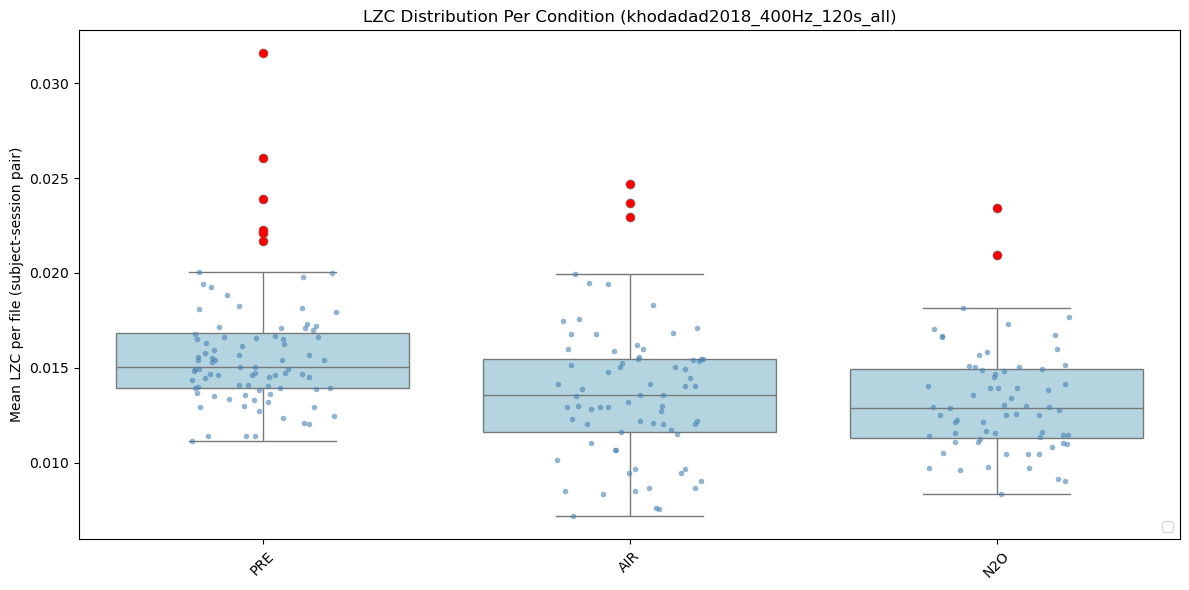

Outlier files:
  ID  Session condition  lzc_mean
P026        2       PRE  0.023882
P026        1       PRE  0.031564
P043        1       PRE  0.022130
P037        1       PRE  0.026048
P073        1       PRE  0.022266
P006        1       PRE  0.021685
P076        2       AIR  0.023700
P067        2       AIR  0.024672
P028        2       AIR  0.022933
P067        1       N2O  0.023419
P063        1       N2O  0.020966


In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

order = ["PRE", "AIR", "N2O"]

plot_df = df.copy()
plot_df["condition"] = pd.NA
plot_df.loc[plot_df["phase"] == 0, "condition"] = "PRE"
plot_df.loc[(plot_df["phase"] == 1) & (plot_df["Drug"] == "Medical Air"), "condition"] = "AIR"
plot_df.loc[(plot_df["phase"] == 1) & (plot_df["Drug"] == "N2O"), "condition"] = "N2O"
plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=order, ordered=True)
plot_df = plot_df.sort_values("condition")

def iqr_outliers(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return (s < low) | (s > high)

plot_df["is_outlier"] = plot_df.groupby("condition")["lzc_mean"].transform(iqr_outliers)


plt.figure(figsize=(12, 6))
# sns.boxplot(data=plot_df, x='condition', y='lzc_mean')


sns.boxplot(data=plot_df, x="condition", y="lzc_mean", color="lightblue")
sns.stripplot(
    data=plot_df[~plot_df["is_outlier"]],
    x="condition", y="lzc_mean",
    color="steelblue", jitter=0.2, alpha=0.6, size=4
)
sns.stripplot(
    data=plot_df[plot_df["is_outlier"]],
    x="condition", y="lzc_mean",
    color="red", jitter=0, size=6
)

plt.xlabel('')
plt.ylabel('Mean LZC per file (subject-session pair)')
plt.title(f'LZC Distribution Per Condition ({METHOD})')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

outliers = plot_df[plot_df["is_outlier"]].copy()
print("Outlier files:")
print(outliers[["ID", "Session", "condition", "lzc_mean"]].to_string(index=False))

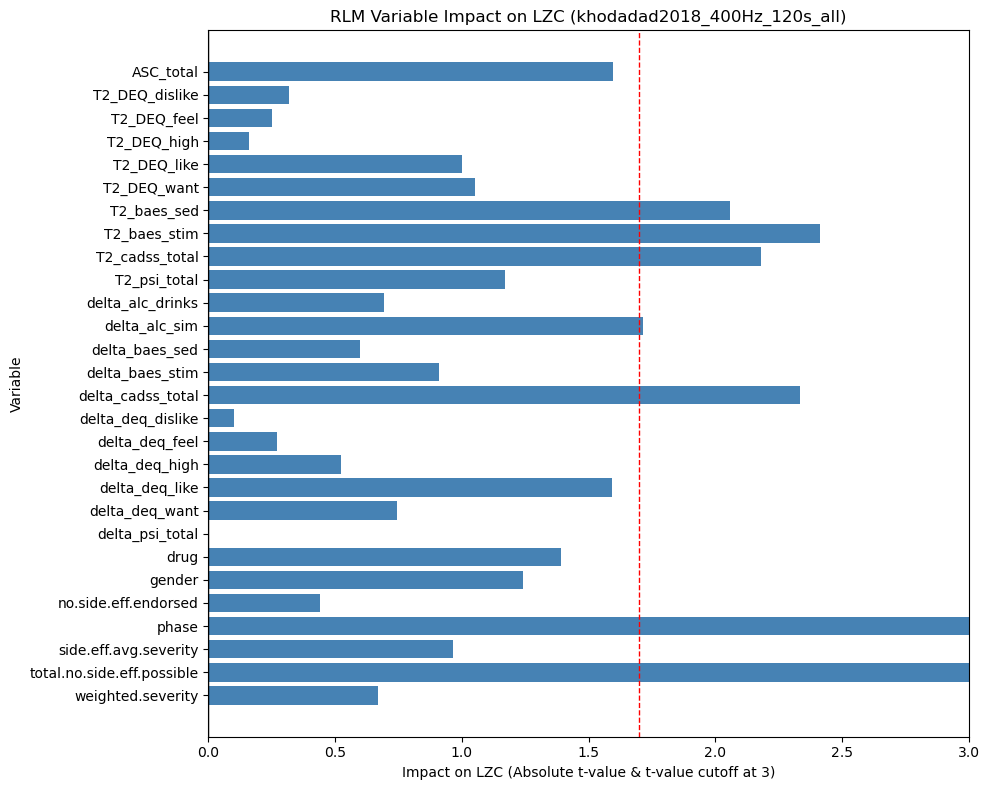


Significant variables:
                  variable p_value p_significant  t_value t_significant
total.no.side.eff.possible 0.00000          True 11.47675          True
                     phase 0.00000          True -6.38667          True
              T2_baes_stim 0.01585          True -2.41242          True
         delta_cadss_total 0.01961          True -2.33371          True
            T2_cadss_total 0.02934          True  2.17889          True
               T2_baes_sed 0.03981          True -2.05575          True
             delta_alc_sim 0.08671         False -1.71302          True


In [94]:
ABSOLUTE_T_VALUES = True
CUTOFF_AXIS_LIMIT = 3
CUTOFF_AXIS = True

# Barplot of variable impact on LZC using t-values from the robust linear model
plot_rlm = rlm.copy()

if ABSOLUTE_T_VALUES:
    plot_rlm["impact"] = abs(plot_rlm["t_value"])
else:
    plot_rlm["impact"] = plot_rlm["t_value"]
plot_rlm = plot_rlm.sort_values("variable", ascending=False)

plt.figure(figsize=(10, 8))
colors = plot_rlm["impact"].apply(lambda x: "steelblue" if x >= 0 else "salmon")

plt.barh(plot_rlm["variable"], plot_rlm["impact"], color=colors)
plt.axvline(0, color="black", linewidth=1)

# significance threshold lines (both sides)
signif = 1.7
plt.axvline(signif, color="red", linestyle="--", linewidth=1)
if not ABSOLUTE_T_VALUES:
    plt.axvline(-signif, color="red", linestyle="--", linewidth=1)

cutoff_text = f" & t-value cutoff at {CUTOFF_AXIS_LIMIT}" if CUTOFF_AXIS else ""
plt.xlabel(f"Impact on LZC ({'Absolute ' if ABSOLUTE_T_VALUES else ''}t-value{cutoff_text})")
plt.ylabel("Variable")
plt.title(f"RLM Variable Impact on LZC ({METHOD})")
if CUTOFF_AXIS and ABSOLUTE_T_VALUES:
    plt.xlim(0, CUTOFF_AXIS_LIMIT)
if CUTOFF_AXIS and not ABSOLUTE_T_VALUES:
    plt.xlim(-CUTOFF_AXIS_LIMIT, CUTOFF_AXIS_LIMIT)
plt.tight_layout()
plt.show()

significant_mask = rlm["p_significant"] | rlm["t_significant"]
print("\nSignificant variables:")
print(
    rlm.loc[significant_mask, ["variable", "p_value", "p_significant", "t_value", "t_significant"]]
    .sort_values(by="t_value", key=lambda s: s.abs(), ascending=False)
    .assign(
        p_value=lambda d: d["p_value"].map(lambda x: f"{x:.5f}"),
        t_value=lambda d: d["t_value"].map(lambda x: f"{x:.5f}"),
    )
    .to_string(index=False)
)